In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [21]:
class SimpleAttention(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.S = None
        self.A = None
        self.O = None

    def call(self, X, mask=None, **kwargs):
        S = X @ tf.transpose(X, perm=[0, 2, 1])


        if mask is not None:
            mask = tf.cast(mask, tf.float32)
            mask = mask[:, tf.newaxis, :]
            S = S + (1.0 - mask) * -1e9


        seq_len = tf.shape(X)[1]
        causal_mask = tf.linalg.band_part(tf.ones((seq_len, seq_len)), -1, 0)
        S = S + (1.0 - causal_mask) * -1e9

        A = tf.nn.softmax(S, axis=-1)
        O = A @ X

        self.S = S
        self.A = A
        self.O = O
        return O

    def get_S(self): return self.S
    def get_A(self): return self.A
    def get_O(self): return self.O

In [22]:
class MultiHeadSimpleAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.supports_masking = True
        self.num_heads = num_heads
        self.embed_dim = embed_dim
        self.heads = [SimpleAttention() for _ in range(num_heads)]
        self.dense = tf.keras.layers.Dense(embed_dim)

    def call(self, X, mask=None, training=False, **kwargs):

        outputs = [head(X, mask=mask) for head in self.heads]

        concat = tf.concat(outputs, axis=-1)
        return self.dense(concat)

In [23]:
vocab = {
    "the":0, "apothecary":1, "diaries":2, "pride":3, "and":4, "prejudice":5, "naruto":6,
    "jojo":7, "bizarre":8, "adventures":9, "is":10, "a":11, "anime":12, "novel":13, "your":14,
    "name":15, "one":16, "piece":17, "harry":18, "potter":19, "stranger":20, "an":21, "best":22,
    "?":23, "isn't":24, "it":25, "barrier":26, ",":27, "of":28, "not":29, "great":30, "classic":31,
    "famous":32, "really":33, "just":34, "good":35, "written":36, "by":37, "camus":38, "austen":39,
    "about":40, "character":41, "story":42, "based":43, "on":44, "manga":45, "series":46, "book":47,
    "people":48, "love":49,
}

phrases = [
    "naruto is the best anime isn't it ?",
    "one piece is a really great anime ,",
    "jojo bizarre adventures is a great anime ,",
    "your name is a famous anime isn't it ?",
    "naruto is a famous anime series isn't it ?",
    "one piece is a classic anime series ,",
    "jojo bizarre adventures is the best anime",
    "the apothecary diaries is a great anime",
    "naruto is based on a great manga series",
    "one piece is based on a famous manga",
    "your name is just a really good anime",
    "jojo bizarre adventures is based on manga ,",
    "the apothecary diaries is not a novel ,",
    "naruto is not a novel it is anime",
    "one piece is not a novel it is anime",
    "pride and prejudice is the best novel ,",
    "harry potter is the best novel isn't it ?",
    "the stranger is a classic novel by camus",
    "pride and prejudice is written by austen ,",
    "harry potter is a famous novel series ,",
    "the stranger is a really good novel ,",
    "pride and prejudice is a classic novel ,",
    "harry potter is based on a great novel",
    "the stranger is not an anime it is novel",
    "pride and prejudice is not an anime ,",
    "harry potter is not anime it is a novel",
    "the stranger is a novel about one character",
    "pride and prejudice is a story about love",
    "harry potter is a novel people really love",
    "the stranger is the best novel by camus",
]



def tokeniser(phrase,vocab):
    mots=phrase.split()
    return [vocab[mot] for mot in mots]
X=[tokeniser(phrase,vocab) for phrase in phrases]
def tokeniser(phrase, vocab):
    mots = phrase.split()
    return [vocab[mot] for mot in mots]

X = [tokeniser(phrase, vocab) for phrase in phrases]
X = pad_sequences(X, maxlen=10, padding='post')
y = np.array(labels)


X = pad_sequences(X, maxlen=10, padding='post')

split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]

y_train_lm = X_train[:, 1:]
X_train_lm = X_train[:, :-1]

y_test_lm = X_test[:, 1:]
X_test_lm = X_test[:, :-1]

In [30]:
@tf.keras.utils.register_keras_serializable()
class TransformerDecoderBlock(tf.keras.layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout_rate=0.1, **kwargs):
        super().__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.ff_dim = ff_dim
        self.dropout_rate = dropout_rate


        self.att = MultiHeadSimpleAttention(num_heads=num_heads, embed_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(ff_dim, activation="relu"),
            tf.keras.layers.Dense(embed_dim),
        ])
        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout1 = tf.keras.layers.Dropout(dropout_rate)
        self.dropout2 = tf.keras.layers.Dropout(dropout_rate)



    def call(self, inputs, training=False, mask=None):

        attn_output = self.att(inputs)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(inputs + attn_output)

        ffn_output = self.ffn(out1)
        ffn_output = self.dropout2(ffn_output, training=training)
        return self.layernorm2(out1 + ffn_output)

        def get_config(self):
            config = super().get_config()
            config.update({
                "embed_dim": self.embed_dim,
                "num_heads": self.num_heads,
                "ff_dim": self.ff_dim,
                "dropout_rate": self.dropout_rate,
            })
            return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [31]:
@tf.keras.utils.register_keras_serializable()

#cette classe est extraite du guide de M P.Poncelet
class PositionalEmbedding(tf.keras.layers.Layer):
    def __init__(self, sequence_length, vocab_size, embed_dim, **kwargs):
        super().__init__(**kwargs)
        self.token_embeddings    = tf.keras.layers.Embedding(input_dim=vocab_size,      output_dim=embed_dim)
        self.position_embeddings = tf.keras.layers.Embedding(input_dim=sequence_length, output_dim=embed_dim)
        self.sequence_length = sequence_length
        self.vocab_size      = vocab_size
        self.embed_dim       = embed_dim

    def call(self, inputs):
        length    = tf.shape(inputs)[-1]
        positions = tf.range(0, length)
        return self.token_embeddings(inputs) + self.position_embeddings(positions)

    def compute_mask(self, inputs, mask=None):
        return tf.not_equal(inputs, 0)
    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size":      self.vocab_size,
            "embed_dim":       self.embed_dim,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [32]:

@tf.keras.utils.register_keras_serializable()
class SmallGPT(tf.keras.Model):
    def __init__(self, sequence_length, vocab_size, embed_dim,
                 num_heads, ff_dim, num_layers, **kwargs):
        super().__init__(**kwargs)
        self.sequence_length = sequence_length
        self.vocab_size      = vocab_size
        self.embed_dim       = embed_dim
        self.num_heads       = num_heads
        self.ff_dim          = ff_dim
        self.num_layers      = num_layers

        self.pos_embedding = PositionalEmbedding(sequence_length, vocab_size, embed_dim)
        self.decoder_blocks = [
            TransformerDecoderBlock(embed_dim, num_heads, ff_dim)
            for _ in range(num_layers)
        ]
        self.layernorm   = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.dropout     = tf.keras.layers.Dropout(0.1)
        self.output_layer = tf.keras.layers.Dense(vocab_size, activation="softmax")

    def call(self, inputs, training=False):
        x = self.pos_embedding(inputs)

        x._keras_mask = None
        for block in self.decoder_blocks:
            x = block(x, training=training)
        x = self.layernorm(x)
        x = self.dropout(x, training=training)
        return self.output_layer(x)

    def get_config(self):
        config = super().get_config()
        config.update({
            "sequence_length": self.sequence_length,
            "vocab_size":      self.vocab_size,
            "embed_dim":       self.embed_dim,
            "num_heads":       self.num_heads,
            "ff_dim":          self.ff_dim,
            "num_layers":      self.num_layers,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

In [36]:
sequence_length = 9
vocab_size      = len(vocab)
embed_dim       = 32
num_heads       = 2
ff_dim          = 64
num_layers      = 1

model = SmallGPT(sequence_length, vocab_size, embed_dim, num_heads, ff_dim, num_layers)
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
model.summary()

history = model.fit(
    X_train_lm, y_train_lm,
    validation_data=(X_test_lm, y_test_lm),
    epochs=20,
    batch_size=8,
    verbose=1
)

Model: "small_gpt_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positional_embedding_6          │ ?                      │   0 (unbuilt) │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_block_6     │ ?                      │   0 (unbuilt) │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ ?                      │   0 (unbuilt) │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 266ms/step - accuracy: 0.0324 - loss: 4.2040 - val_accuracy: 0.0370 - val_loss: 3.8141
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.0926 - loss: 3.6549 - val_accuracy: 0.1667 - val_loss: 3.4080
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.2639 - loss: 3.2593 - val_accuracy: 0.3148 - val_loss: 3.1158
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.3611 - loss: 2.9284 - val_accuracy: 0.3889 - val_loss: 2.9118
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.4398 - loss: 2.6842 - val_accuracy: 0.4630 - val_loss: 2.7600
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.4537 - loss: 2.4889 - val_accuracy: 0.5000 - val_loss: 2.6329
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - accuracy: 0.5000 - loss: 2.3326 - val_accuracy: 0.4815 - val_loss: 2.5314
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5741 - loss: 2.1798 - val_accuracy: 0.5370 - val_loss: 2.4479

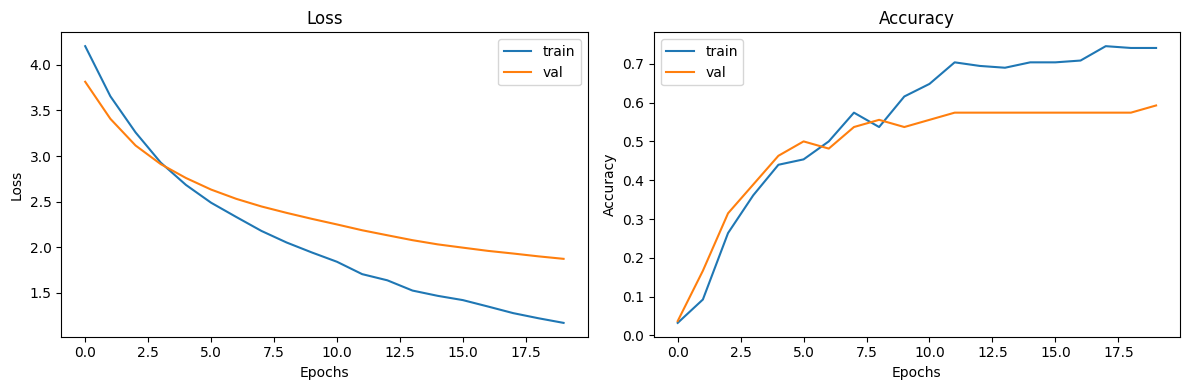

Model: "small_gpt_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ positional_embedding_6          │ ?                      │         1,888 │
│ (PositionalEmbedding)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_decoder_block_6     │ ?                      │         6,400 │
│ (TransformerDecoderBlock)       │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer_normalization_17          │ (8, 9, 32)             │            64 │
│ (LayerNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_20 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (8, 9, 50)             │         1,650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,008 (117.22 KB)

 Trainable params: 10,002 (39.07 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 20,006 (78.15 KB)

In [37]:
import matplotlib.pyplot as plt
def afficher_courbes(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))


    ax1.plot(history.history['loss'], label='train')
    ax1.plot(history.history['val_loss'], label='val')
    ax1.set_title('Loss')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Loss')
    ax1.legend()


    ax2.plot(history.history['accuracy'], label='train')
    ax2.plot(history.history['val_accuracy'], label='val')
    ax2.set_title('Accuracy')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Accuracy')
    ax2.legend()

    plt.tight_layout()
    plt.show()

afficher_courbes(history)
model.summary()

In [38]:
def generer(model, prompt, vocab, sequence_length, num_mots=5):

    index_to_word = {v: k for k, v in vocab.items()}

    tokens = [vocab[mot] for mot in prompt.split()]

    for _ in range(num_mots):

        seq = tokens[-sequence_length:]
        seq = pad_sequences([seq], maxlen=sequence_length, padding='post')


        pred = model(seq)
        last_pos = len(tokens) - 1
        next_token = tf.argmax(pred[0, last_pos]).numpy()

        tokens.append(next_token)
        mot = index_to_word.get(next_token, "?")
        print(f"→ {mot}", end=" ")

    print()


generer(model, "naruto is", vocab, sequence_length, num_mots=5)
generer(model, "pride and prejudice is", vocab, sequence_length, num_mots=4)

→ a → famous → anime → series → isn't 
→ the → best → novel → , 
